In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import branes
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from sklearn.decomposition import PCA
import glob
import os
from scipy.stats import skellam

In [3]:
plt.style.use(['science', 'dark_background', 'bright'])

## Main loop

[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/'
[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/T'
[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/K'
[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/S'
[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/TK'
[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/TS'
[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/KS'
[WinError 183] Cannot create a file when that file already exists: 'models/bix2=000/UI=01010102/TKS'
Run  1


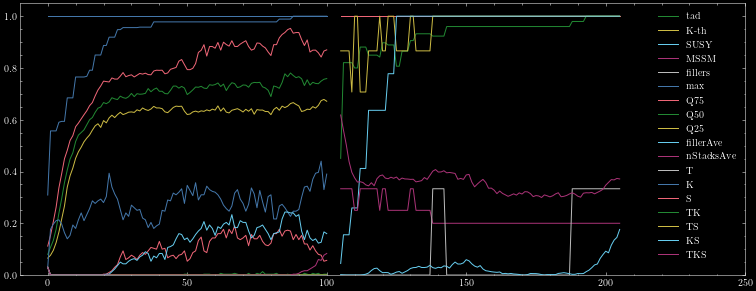

First TKS : generation 88
	n   |      2     3     4     5     6     7     8 | total
	--------------------------------------------------------
	T   |                                            |      
	K   |   3415  2013   813   252    97    30    11 |  6631
	S   |    400   381   131    31     7     1     1 |   952
	TK  |      3     8                               |    11
	TS  |                                            |      
	KS  |    274   189    76    18     5             |   562
	TKS |            1                               |     1

 Na |  n1  m1  n2  m2  n3  m3   |   X0  X1  X2  X3   |   Y0  Y1  Y2  Y3
------------------------------------------------------------------------
  8 |   1   1   1  -1   1   0   |    1           1   |       -1   1    
  4 |   1   0   0   1   0  -1   |        1           |                 
  4 |   1   1   2   1   0  -1   |        1   2       |   -1           2
                                  --------------------------------------
                 

In [67]:
# GA meta parameters
nRuns = 5
nGens = 100
popSize = 300
nSurvive = 15

# Environment parameters
maxStacks = 8
bix2 = np.array([0, 0, 0])
UI = np.array([1, 1, 1, 2])
filler = False
signfix = False

# Cross-over probabilities
# xoverProbs = [0.4, 0.4, 0.05, 0.05]
xoverProbs = [0.23, 0.23, 0.23, 0.23]

# Mutation parameters
mutStckSplt = 0
mutStckAdd  = 0
mutStckComb = 0.5
mutStckDel  = 0.05
mutStckPerm = 0.05

mutNaPM     = 0.2
mutWindPM   = 0.4
mutWindPerm = 0.25
mutWindSgns = 0.1

mutRates = [mutStckSplt, mutStckAdd, mutStckComb, mutStckDel, mutStckPerm,
            mutNaPM, mutWindPM, mutWindPerm, mutWindSgns]

# Fitness parameters
weights = [0.55, 0.05, 0.4, 0]
tadScale = 24
susyScale = 0.5

# File management etc.
rnd = "".join([str(d) for d in np.random.randint(10, size=10)])
tksFolder = ('models/bix2=%d%d%d/UI=%02d%02d%02d%02d/' % (bix2[0], bix2[1], bix2[2], UI[0], UI[1], UI[2], UI[3]))
tksFileName = ''
fillFilePath = ('filler_histories/bix2=%d%d%d_UI=%02d%02d%02d%02d.npy' \
                % (bix2[0], bix2[1], bix2[2], UI[0], UI[1], UI[2], UI[3]))

optFileName = ('results/bix2=%d%d%d/UI=%02d%02d%02d%02d/' % (bix2[0], bix2[1], bix2[2], UI[0], UI[1], UI[2], UI[3])) \
              + tksFileName

for s in ["", "T", "K", "S", "TK", "TS", "KS", "TKS"]:
    try:
        os.mkdir(tksFolder + s)
    except IOError as err:
        print(err)

progress = True
saveTKS = False
saveFill = False
saveOpt = False

# Run!
rewards = branes.GA(nRuns, nGens, popSize, nSurvive, bix2, UI, maxStacks, filler, signfix,
          xoverProbs, mutRates,
          weights, tadScale, susyScale,
          progress,
          saveTKS, tksFolder, tksFileName,
          saveFill, fillFilePath,
          saveOpt, optFileName)

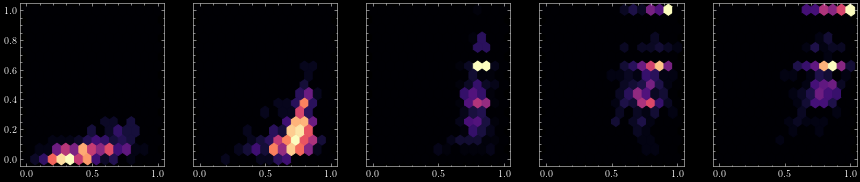

In [88]:
gList = [5, 10, 20, 50, 100]
fig, ax = plt.subplots(1, len(gList), figsize=(15,3), sharex=True, sharey=True)
for i in range(len(gList)):
    g = gList[i]
    ax[i].hexbin(rewards[g,:,0], rewards[g,:,2], gridsize=15, extent=(0,1,0,1), cmap='magma')
plt.show()

## Optimization

### Scales

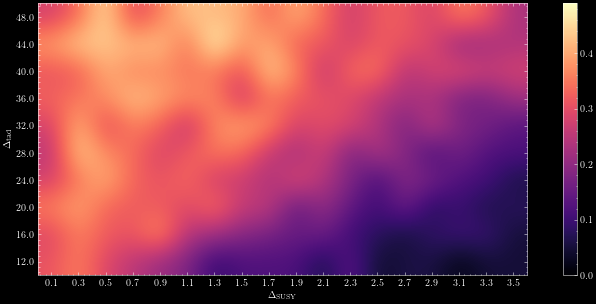

In [4]:
# files = glob.glob('condor/tad_susy_scales_v1/*/*.npy')
files = glob.glob('condor/tad_susy_scales_v2/*/*.npy')

tadScaleList = np.array([int(f[141:144])/10 for f in files])
susyScaleList = np.array([int(f[150:152])/10 for f in files])

successCounts = np.array([np.load(f) for f in files])

tadScales = np.unique(tadScaleList)
susyScales = np.unique(susyScaleList)

counts = np.zeros([len(tadScales), len(susyScales), 2])

for i in range(len(tadScales)):
    for j in range(len(susyScales)):
        whr = np.where((tadScaleList == tadScales[i]) * (susyScaleList == susyScales[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='bicubic', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(tadScales)), labels=tadScales)
plt.xticks(range(len(susyScales)), labels=susyScales)
plt.xlabel(r'$\Delta_\text{SUSY}$')
plt.ylabel(r'$\Delta_\text{tad}$')

# plt.savefig('scales_v1.png')
# plt.savefig('scales_v2.png')

plt.show()

### Weights & tadscale

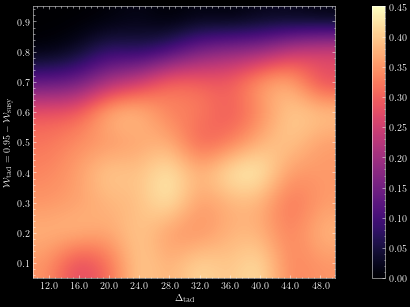

In [5]:
files = glob.glob('condor/weights_tadscale_v1/*/*.npy')

tadWeightList = np.array([int(f[128:131])/100 for f in files])
tadScaleList = np.array([int(f[142:145])/10 for f in files])

successCounts = np.array([np.load(f) for f in files])

tadWeights = np.unique(tadWeightList)
tadScales = np.unique(tadScaleList)

counts = np.zeros([len(tadWeights), len(tadScales), 2])

for i in range(len(tadWeights)):
    for j in range(len(tadScales)):
        whr = np.where((tadWeightList == tadWeights[i]) * (tadScaleList == tadScales[j]))[0]
        counts[i,j] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,0] / (counts[:,:,0] + counts[:,:,1])

fig, ax = plt.subplots(1, 1, figsize=(13,5))
im = plt.imshow(probs, origin='lower', cmap='magma', interpolation='bicubic', vmin=0)
plt.colorbar(im)
plt.yticks(range(len(tadWeights)), labels=tadWeights)
plt.xticks(range(len(tadScales)), labels=tadScales)
plt.xlabel(r'$\Delta_\text{tad}$')
plt.ylabel(r'$\mathcal{W}_\text{tad}=0.95-\mathcal{W}_\text{susy}$')

# plt.savefig('weights_scales_v1.png')

plt.show()

### Cross-over probabilities
These are parametrized by $x,y,c\in[0,1]$ as

|Method<img width=100/>|probability <img width=200/>|
|---|---|
|stack | $(1-c)\cos^2{(\frac{\pi}{2}x)}\cos^2{(\frac{\pi}{2}y)}$ |
|stack (const) | $(1-c)\sin^2{(\frac{\pi}{2}x)}\cos^2{(\frac{\pi}{2}y)}$ |
|gene| $(1-c)\cos^2{(\frac{\pi}{2}x)}\sin^2{(\frac{\pi}{2}y)}$ |
|gene (const)| $(1-c)\sin^2{(\frac{\pi}{2}x)}\sin^2{(\frac{\pi}{2}y)}$ |
|clone| $c$ |

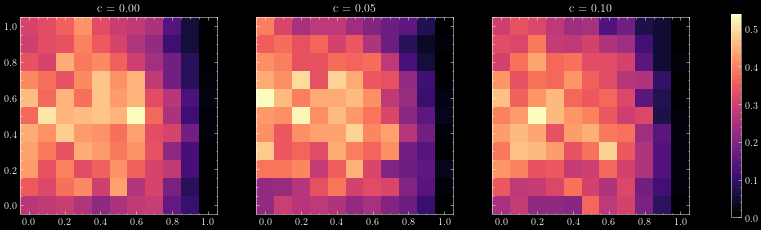

In [29]:
files = glob.glob('condor/pxo_xycparam_v2/*/*.npy')

xList = [int(f[56:59])/100 for f in files]
yList = [int(f[62:65])/100 for f in files]
cList = [int(f[68:70])/100 for f in files]

successCounts = np.array([np.load(f) for f in files])

xx = np.unique(xList)
yy = np.unique(yList)
cc = np.unique(cList)

counts = np.zeros([len(xx), len(yy), len(cc), 2])

for i in range(len(xx)):
    for j in range(len(yy)):
        for k in range(len(cc)):
            whr = np.where((xList == xx[i]) * (yList == yy[j]) * (cList == cc[k]))[0]
            counts[i,j,k] = np.sum(successCounts[whr], axis=0)

probs = counts[:,:,:,0] / (counts[:,:,:,0] + counts[:,:,:,1])

fig, ax = plt.subplots(1, len(cc), figsize=(15,5), sharex=True, sharey=True)

for i in range(len(cc)):
    im = ax[i].imshow(probs[:,:,i].T, origin='lower', cmap='magma', interpolation='none', vmin=0)
    ax[i].set_title('c = %.2f' % cc[i])
plt.colorbar(im, ax=ax, shrink=0.75)
plt.xticks(np.arange(0,len(xx),2), labels=xx[::2])
plt.yticks(np.arange(0,len(yy),2), labels=yy[::2])

# plt.savefig('pxo_xycparam_v1.png')

plt.show()

## Statistics

In [29]:
TKSstrings = ["T", "K", "S", "TK", "TS", "KS", "TKS"]

In [30]:
counts = np.zeros([len(TKSstrings)], dtype='int')
Ns = np.zeros([len(TKSstrings), 15], dtype='int')
rank = np.zeros([len(TKSstrings), 30], dtype='int')
nmpairs = np.zeros([len(TKSstrings), 12, 12], dtype='int')

for i in range(len(TKSstrings)):
    files = glob.glob("models/bix2=000_ns=3/UI=*/" + TKSstrings[i] + "/*.npy")
    models = [np.load(f) for f in files]
    models = np.array([a for b in models for a in b])
    counts[i] = len(models)
    for model in models:
        r = sum(model[:,0])
        if r < len(rank[i]):
            rank[i,r] += 1
        for stack in model:
            if stack[0] < len(Ns[i]):
                Ns[i, stack[0]] += 1
            for j in range(3):
                n, m = np.sort(abs(stack[2*j+1:2*j+3]))
                if m < len(nmpairs[i]):
                    nmpairs[i, n, m] += 1

C:\Users\gerg1\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\gerg1\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.
C:\Users\gerg1\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\gerg1\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: RuntimeWarning: invalid value encountered in true_divide
  after removing the cwd from sys.path.
C:\Users\gerg1\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\gerg1\Anaconda3\lib\site-packages\ipyker

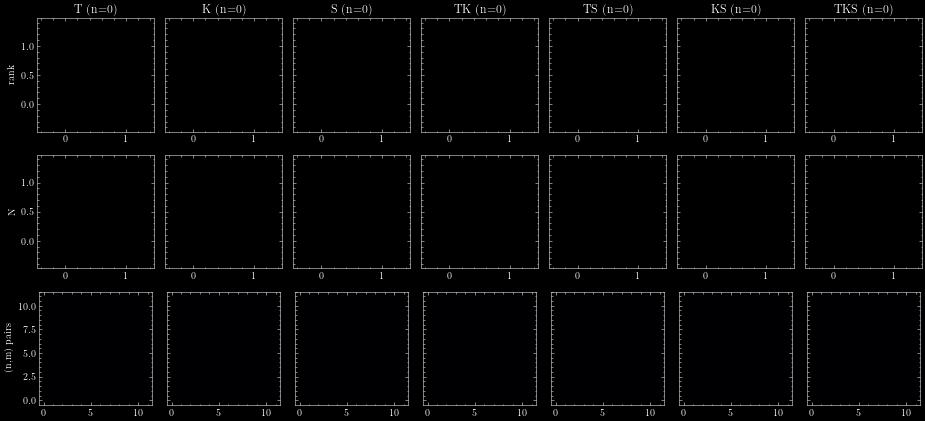

In [31]:
fig, ax = plt.subplots(3, 7, figsize=(13,6), sharex='row', sharey='row')
for i in range(len(TKSstrings)):
    ax[0,i].step(range(len(rank[0])), rank[i]/sum(rank[i]), c='chartreuse', where='mid')
    ax[1,i].step(range(len(Ns[0])), Ns[i]/sum(Ns[i]), c='chartreuse', where='mid')
    ax[2,i].imshow(nmpairs[i], origin='lower', norm=colors.LogNorm(), cmap='magma')
    ax[0,i].set_title(TKSstrings[i] + " (n=" + str(counts[i]) + ")")
ax[0,0].set_ylabel('rank')
ax[1,0].set_ylabel('N')
ax[2,0].set_ylabel('(n,m) pairs')
plt.tight_layout()
plt.show()

## Learning fillers

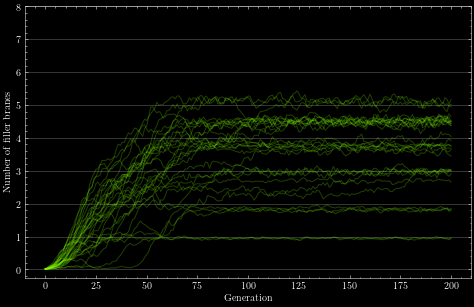

In [101]:
ns = 5
files = glob.glob("filler_histories/*_ns=%d_*.npy" % ns)
fillHists = [np.load(f) for f in files]
fillHists = [a for b in fillHists for a in b]

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.grid(axis='y', c='dimgray')
for data in fillHists:
    ax.plot(data, c='chartreuse', alpha=0.25)
ax.set_yticks(range(ns + 1))
ax.set_xlabel('Generation')
ax.set_ylabel('Number of filler branes')

# plt.savefig("fillHist_ns=%d.png" % ns, dpi=200)

plt.show()

## Statistics

[0.50390649 0.13374165 0.10587118 0.04191906]


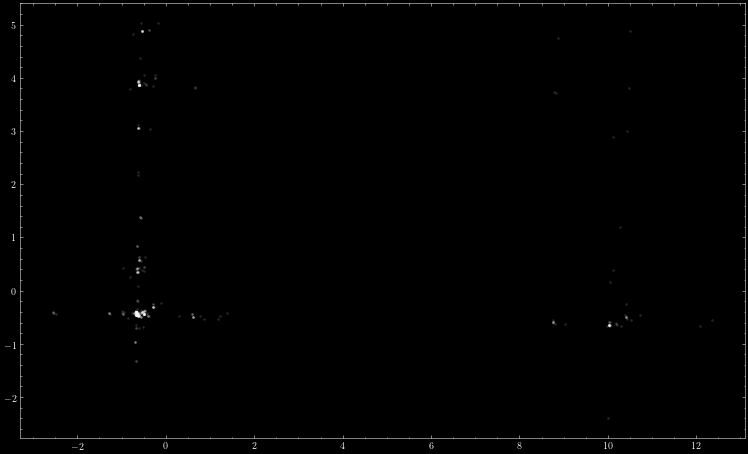

In [4]:
files = glob.glob('sample_populations/bix2=000_ns=5_success=*/*.npy')
pop = np.load(files[np.random.randint(len(files))])
popFlat = np.array([e.ravel() for e in pop])

pca = PCA(n_components=4)
Xr = pca.fit_transform(popFlat)

print(pca.explained_variance_ratio_)

fig, ax = plt.subplots(1, 1, figsize=(13,8))
ax.scatter(Xr[:,0], Xr[:,1], s=3, alpha=0.1, c='w')
plt.show()

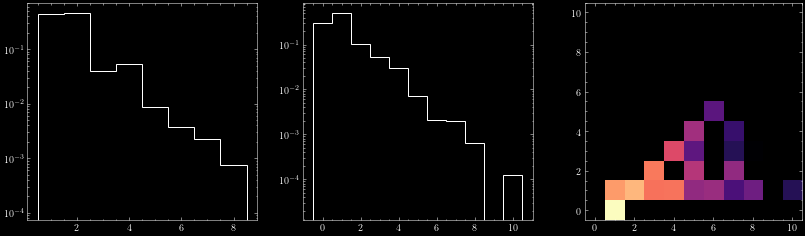

In [5]:
file = glob.glob('consistent_models/bix2=000_ns=5.npy')[0]
cons = np.load(file)

Ns = [c[:,0].ravel() for c in cons]
ws = [abs(c[:,1:].ravel()) for c in cons]
Ns = [a for b in Ns for a in b]
ws = [a for b in ws for a in b]

nmpairs = np.zeros([max(ws)+1, max(ws)+1], dtype='int')

for c in cons:
    for stack in c:
        for i in range(3):
            n, m = stack[2*i+1:2*i+3]
            minnm, maxnm = np.sort(np.abs([n, m]))
            nmpairs[minnm, maxnm] += 1


fig, ax = plt.subplots(1, 3, figsize=(14,4))

ax[0].hist(Ns, np.arange(0.5, max(Ns)+1, 1), align='mid', density=True, log=True, histtype='step', color='w')
ax[1].hist(ws, np.arange(-0.5, max(ws)+1, 1), align='mid', density=True, log=True, histtype='step', color='w')
ax[2].imshow(nmpairs, origin='lower', norm=colors.LogNorm(), cmap='magma')

plt.show()

In [121]:
for i in np.arange(0, 1.01, 0.05):
    for j in np.arange(0, 1.01, 0.05):
        print("%.2f" % i, "%.2f" % j)

0.00 0.00
0.00 0.05
0.00 0.10
0.00 0.15
0.00 0.20
0.00 0.25
0.00 0.30
0.00 0.35
0.00 0.40
0.00 0.45
0.00 0.50
0.00 0.55
0.00 0.60
0.00 0.65
0.00 0.70
0.00 0.75
0.00 0.80
0.00 0.85
0.00 0.90
0.00 0.95
0.00 1.00
0.05 0.00
0.05 0.05
0.05 0.10
0.05 0.15
0.05 0.20
0.05 0.25
0.05 0.30
0.05 0.35
0.05 0.40
0.05 0.45
0.05 0.50
0.05 0.55
0.05 0.60
0.05 0.65
0.05 0.70
0.05 0.75
0.05 0.80
0.05 0.85
0.05 0.90
0.05 0.95
0.05 1.00
0.10 0.00
0.10 0.05
0.10 0.10
0.10 0.15
0.10 0.20
0.10 0.25
0.10 0.30
0.10 0.35
0.10 0.40
0.10 0.45
0.10 0.50
0.10 0.55
0.10 0.60
0.10 0.65
0.10 0.70
0.10 0.75
0.10 0.80
0.10 0.85
0.10 0.90
0.10 0.95
0.10 1.00
0.15 0.00
0.15 0.05
0.15 0.10
0.15 0.15
0.15 0.20
0.15 0.25
0.15 0.30
0.15 0.35
0.15 0.40
0.15 0.45
0.15 0.50
0.15 0.55
0.15 0.60
0.15 0.65
0.15 0.70
0.15 0.75
0.15 0.80
0.15 0.85
0.15 0.90
0.15 0.95
0.15 1.00
0.20 0.00
0.20 0.05
0.20 0.10
0.20 0.15
0.20 0.20
0.20 0.25
0.20 0.30
0.20 0.35
0.20 0.40
0.20 0.45
0.20 0.50
0.20 0.55
0.20 0.60
0.20 0.65
0.20 0.70
0.20 0.75
